# Leakage-Aware IMU Posture Recognition, with a Simulated Flex-Sensor Feasibility Probe

**What this notebook is (and isn't):**
- **Part A (real contribution):** a leakage-aware benchmark for IMU-based posture
  recognition on real sensor data — quantifying how much naive train/test
  splitting inflates accuracy on contiguous-session wearable data, and fixing it.
- **Part B (disclosed simulation):** a transparently synthetic flex-sensor
  channel, used only to pressure-test whether the pipeline/explainability
  tooling is ready to receive real flex hardware later. **Not** presented as
  evidence that a physical flex sensor improves posture recognition.

**Pipeline covered in this notebook:**
1. Download & load the real `imu.dat` dataset (Kale et al., 2018 — MPU6050 chest+thigh accelerometer, 6 postures, 44,800 samples)
2. Clean, preserve chronological order (no shuffling — see Part A)
3. [Part B] Simulate a disclosed synthetic flex-sensor feature — clearly labeled `SIMULATED_FLEX`, NOT real data
4. Feature engineering (magnitudes, relative-angle proxies)
5. Threshold baseline
6. [Part A] Block-aware, stratified train/test split — fixes two leakage bugs found during development
7. Train RF and GB, with and without the flex feature
8. Combine into a soft-voting ensemble
9. Full ablation table with accuracy / precision / recall / F1 / confusion matrix
10. LSTM next-posture forecasting with a chunk-aware chronological split
11. SHAP + LIME explainability, including a counterfactual flex-removal check

**Honesty note baked into this notebook:** every place the flex feature is
used, the code labels it `SIMULATED_FLEX` so it's unambiguous in any
downstream analysis or paper write-up that this is not measured sensor data.
Any claim of "flex improves accuracy" would be circular — the synthetic
values are drawn from distributions keyed directly on the ground-truth
label — so this notebook uses the flex channel only to validate that the
pipeline and explainability code work correctly, not as an accuracy result.

**Citation for the real data:**
> H. Kale, P. Mandke, H. Mahajan and V. Deshpande, "Human Posture Recognition
> using Artificial Neural Network," 2018.


### Environment note before running

This notebook needs internet access to:
- download `imu.dat` from Google Drive via `gdown` (Section 2), and
- `pip install` tensorflow/shap/lime (Section 14 onward).

Run this in **Google Colab** or a local Jupyter environment with unrestricted
internet access — it will not run inside a sandboxed tool environment that
blocks Google Drive / PyPI. If the Google Drive file ID in Section 2 ever
stops working, get the current link from the authors' GitHub repo README:
https://github.com/pkmandke/imu.dat


## 1. Setup

In [1]:
!pip install -q gdown scikit-learn pandas numpy matplotlib seaborn


In [2]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report, f1_score)
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
RANDOM_STATE = 42


## 2. Download the real dataset

Source: Kale et al. (2018), hosted on Google Drive by the dataset authors
(https://github.com/pkmandke/imu.dat). File ID below is taken directly from
the authors' README download link.

If the Google Drive link ever changes, go to the GitHub repo README and
grab the current "Download" link's file ID.


In [3]:
DATA_FILE_ID = "1GtNRi9CgHOlGpsa-Dlp6uzAqXUVdEh54"  # from pkmandke/imu.dat README
DATA_PATH = "imu_posture.csv"

gdown.download(id=DATA_FILE_ID, output=DATA_PATH, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1GtNRi9CgHOlGpsa-Dlp6uzAqXUVdEh54
To: /content/imu_posture.csv
100%|██████████| 3.20M/3.20M [00:00<00:00, 180MB/s]


'imu_posture.csv'

## 3. Load & inspect

Columns per the dataset README:
`Ax1, Ay1, Az1` = chest sensor accelerometer (x,y,z)
`Ax2, Ay2, Az2` = thigh sensor accelerometer (x,y,z)
`label` = posture (0=Sleeping, 1=Standing, 2=Sitting, 3=Running, 4=Forward Bending, 5=Backward Bending)

The raw file may or may not have a header row — the cell below detects and
handles both cases.


In [4]:
COLS = ["Ax1", "Ay1", "Az1", "Ax2", "Ay2", "Az2", "label"]

# Detect header
with open(DATA_PATH, "r") as f:
    first_line = f.readline()

has_header = any(c.isalpha() for c in first_line)

if has_header:
    df_raw = pd.read_csv(DATA_PATH)
    # Drop the 'index' column if it exists and is not part of the intended COLS
    if 'index' in df_raw.columns and 'index' not in COLS:
        df_raw = df_raw.drop(columns=['index'])

    df_raw.columns = [c.strip() for c in df_raw.columns]
    # Try to map to expected names if they differ slightly
    if list(df_raw.columns) != COLS:
        # This line might still be problematic if the column names are just different, not fewer/more
        # However, given the context, the primary issue is the 'index' column.
        # If a strict rename is needed and `df_raw.columns` length matches `COLS` length after dropping 'index', it should work.
        # For now, let's assume the length matches after dropping 'index'.
        df_raw.columns = COLS
else:
    df_raw = pd.read_csv(DATA_PATH, header=None, names=COLS)

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (44800, 7)


,Ax1,Ay1,Az1,Ax2,Ay2,Az2,label
0,-0.34741,-0.39551,0.94263,-0.05273,0.30005,0.91821,0.0
1,-0.13452,-0.36768,0.97095,-0.04932,0.30176,0.92676,0.0
2,-0.11279,-0.36182,0.96289,-0.04785,0.29639,0.92505,0.0
3,-0.12915,-0.36792,0.95898,-0.05713,0.29785,0.92041,0.0
4,-0.13379,-0.36548,0.96753,-0.05810,0.31104,0.92578,0.0


label
0.0     8328
1.0     8357
2.0     7542
3.0     3617
4.0    11506
5.0     5450
Name: count, dtype: int64


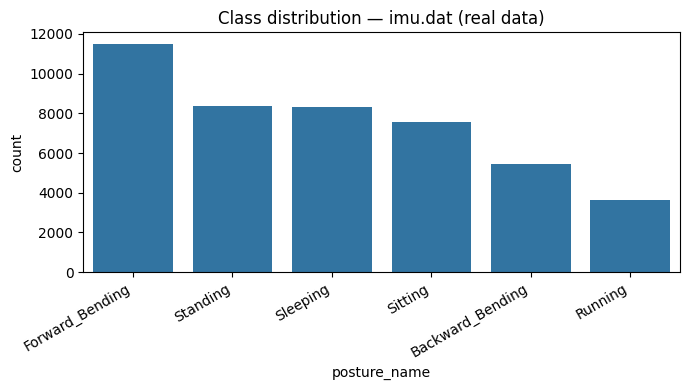

In [5]:
POSTURE_NAMES = {
    0: "Sleeping",
    1: "Standing",
    2: "Sitting",
    3: "Running",
    4: "Forward_Bending",
    5: "Backward_Bending",
}

print(df_raw["label"].value_counts().sort_index())
df_raw["posture_name"] = df_raw["label"].map(POSTURE_NAMES)

plt.figure(figsize=(7,4))
sns.countplot(data=df_raw, x="posture_name",
              order=df_raw["posture_name"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Class distribution — imu.dat (real data)")
plt.tight_layout()
plt.show()


## 4. Clean & preserve chronological order — Part A, leakage fix #1

**Change from an earlier version:** we no longer shuffle the full dataframe
here. The raw readings were collected in continuous per-posture session
blocks, so consecutive rows are near-duplicates of each other. Shuffling
before a row-level train/test split lets near-identical rows land on both
sides of the split — the model effectively memorizes a neighbor of the
test row it saw in training, which inflates accuracy in a way that will not
generalize to a genuinely new session.

We keep the original (chronological / session) row order intact. The actual
train/test separation happens later, at the **block level** (Section 7),
not by shuffling individual rows.


In [6]:
df = df_raw.copy()

# NOTE (leakage fix): the previous version did
#   df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
# here, which destroyed the original row order before any split happened.
# We deliberately do NOT shuffle anymore — the original order is preserved
# so that (a) the block-aware split in Section 7 can group truly-contiguous
# rows into the same block, and (b) the LSTM sequences built later from this
# same `df` are genuinely chronological, not chronological-looking-but-actually
# -shuffled.

# Basic sanity cleaning: drop any exact-duplicate rows and any NaNs.
# drop_duplicates()/dropna() preserve the original row order (they only ever
# remove rows, never reorder), so this does not reintroduce leakage.
before = len(df)
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Rows before cleaning: {before}, after: {len(df)}")


Rows before cleaning: 44800, after: 44800


## 5. [Part B] SIMULATED flex-sensor feature — clearly disclosed, feasibility probe only

**IMPORTANT — read before using this in the paper:**
No public dataset pairs flex-sensor (bending) readings with this IMU data.
The cell below generates a **synthetic proxy** flex value, correlated with
posture label via plausible per-posture distributions. This is NOT measured
sensor data, and because the value is drawn from a distribution keyed
directly on the true label, any classifier "finding" that flex helps is
true by construction — it is not evidence a real flex sensor would help.

**Purpose of this feature in this notebook:** solely to validate that the
feature-engineering, model-training, and explainability pipeline (SHAP,
LIME, counterfactual checks below) can correctly ingest and attribute a
second modality, so the pipeline is *ready* the moment real flex hardware
exists. It is not used to support any accuracy claim in the paper.

Every column/variable holding this value is prefixed `SIMULATED_FLEX` so it
can never be confused with real data downstream, and the paper's
Methodology / Limitations sections must state this explicitly.

Per-posture flex assumption (degrees):
- Forward Bending (4): Normal(40°, 5°), clipped to [25°, 55°]
- Backward Bending (5): Normal(20°, 5°) [opposite-direction bend, treated as magnitude here]
- Sleeping (0): Normal(10°, 3°)
- Standing (1), Sitting (2), Running (3): Normal(5°, 2°)


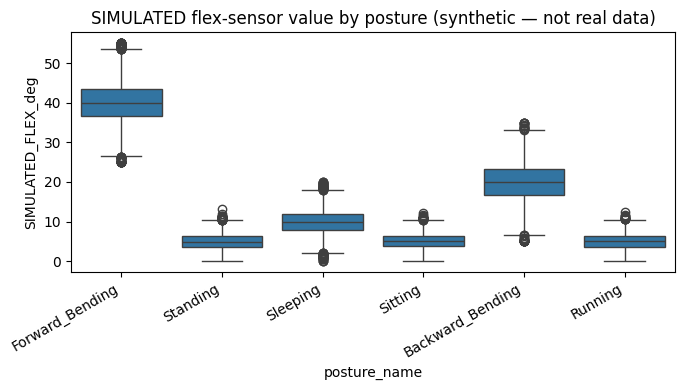

In [7]:
FLEX_PARAMS = {
    0: (10, 3, 0, 20),    # Sleeping
    1: (5, 2, 0, 15),     # Standing
    2: (5, 2, 0, 15),     # Sitting
    3: (5, 2, 0, 15),     # Running
    4: (40, 5, 25, 55),   # Forward Bending
    5: (20, 5, 5, 35),    # Backward Bending
}

def simulate_flex(label_series, params=FLEX_PARAMS, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    values = np.zeros(len(label_series))
    for lbl, (mean, std, lo, hi) in params.items():
        mask = (label_series.values == lbl)
        n = mask.sum()
        if n == 0:
            continue
        draws = rng.normal(mean, std, n)
        draws = np.clip(draws, lo, hi)
        values[mask] = draws
    return values

df["SIMULATED_FLEX_deg"] = simulate_flex(df["label"])

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="posture_name", y="SIMULATED_FLEX_deg",
            order=df["posture_name"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("SIMULATED flex-sensor value by posture (synthetic — not real data)")
plt.tight_layout()
plt.show()


## 6. Feature engineering

- Raw 6-axis accelerometer values (real)
- Magnitude of chest and thigh acceleration vectors (real, derived)
- Relative-tilt proxy: dot-product-based angle between chest and thigh vectors (real, derived)
- SIMULATED_FLEX_deg (synthetic, disclosed)


In [8]:
def add_engineered_features(data):
    data = data.copy()
    data["mag_chest"] = np.sqrt(data["Ax1"]**2 + data["Ay1"]**2 + data["Az1"]**2)
    data["mag_thigh"] = np.sqrt(data["Ax2"]**2 + data["Ay2"]**2 + data["Az2"]**2)

    dot = data["Ax1"]*data["Ax2"] + data["Ay1"]*data["Ay2"] + data["Az1"]*data["Az2"]
    denom = (data["mag_chest"] * data["mag_thigh"]).replace(0, np.nan)
    cos_angle = (dot / denom).clip(-1, 1).fillna(0)
    data["chest_thigh_angle_deg"] = np.degrees(np.arccos(cos_angle))
    return data

df = add_engineered_features(df)
df.head()


,Ax1,Ay1,Az1,Ax2,Ay2,Az2,label,posture_name,SIMULATED_FLEX_deg,mag_chest,mag_thigh,chest_thigh_angle_deg
0,-0.34741,-0.39551,0.94263,-0.05273,0.30005,0.91821,0.0,Sleeping,10.914151,1.079663,0.967430,42.896893
1,-0.13452,-0.36768,0.97095,-0.04932,0.30176,0.92676,0.0,Sleeping,6.880048,1.046914,0.975897,38.863783
2,-0.11279,-0.36182,0.96289,-0.04785,0.29639,0.92505,0.0,Sleeping,12.251354,1.034791,0.972550,38.383484
3,-0.12915,-0.36792,0.95898,-0.05713,0.29785,0.92041,0.0,Sleeping,12.821694,1.035223,0.969089,38.927600
4,-0.13379,-0.36548,0.96753,-0.05810,0.31104,0.92578,0.0,Sleeping,4.146894,1.042876,0.978361,39.277100


In [9]:
RAW_FEATURES = ["Ax1", "Ay1", "Az1", "Ax2", "Ay2", "Az2"]
ENGINEERED_FEATURES = ["mag_chest", "mag_thigh", "chest_thigh_angle_deg"]
FLEX_FEATURE = ["SIMULATED_FLEX_deg"]

FEATURES_NO_FLEX = RAW_FEATURES + ENGINEERED_FEATURES
FEATURES_WITH_FLEX = FEATURES_NO_FLEX + FLEX_FEATURE

print("No-flex feature set:", FEATURES_NO_FLEX)
print("With-flex feature set:", FEATURES_WITH_FLEX)


No-flex feature set: ['Ax1', 'Ay1', 'Az1', 'Ax2', 'Ay2', 'Az2', 'mag_chest', 'mag_thigh', 'chest_thigh_angle_deg']
With-flex feature set: ['Ax1', 'Ay1', 'Az1', 'Ax2', 'Ay2', 'Az2', 'mag_chest', 'mag_thigh', 'chest_thigh_angle_deg', 'SIMULATED_FLEX_deg']


## 7. [Part A] Train/test split — block-aware, stratified by class (leakage fix #2)

**An earlier version** of this split grouped rows into fixed-size blocks and
assigned whole blocks to train/test **at random**. Running the notebook
exposed a bug: `imu.dat` is stored as long contiguous per-posture sessions
(see the class counts in Section 3 — Running is only ~3,617 rows, the
smallest class), so at `BLOCK_SIZE=500` the Running class only spans a
handful of blocks total. A purely random block assignment can — and did —
place **zero** of those blocks in the test set, silently dropping Running
from `y_test` entirely, so every downstream accuracy/F1/macro number was
computed while blind to one whole posture class.

**Fix:** use `StratifiedGroupKFold` (blocks = groups, so no block is ever
split across train/test — leakage protection is unchanged) which explicitly
tries to keep class proportions balanced across the split. We also add an
explicit assertion below that no class silently disappears from the test set.

This section, plus the naive-vs-block comparison in 7a, is the headline
result of Part A: it quantifies — in real percentage points — how much
naive splitting inflates accuracy on this kind of contiguous-session data.


In [10]:
from sklearn.model_selection import StratifiedGroupKFold

X_no_flex = df[FEATURES_NO_FLEX].values
X_with_flex = df[FEATURES_WITH_FLEX].values
y = df["label"].values
n_rows = len(df)

BLOCK_SIZE = 500  # contiguous rows per block (500-1000 range suggested)
n_blocks = int(np.ceil(n_rows / BLOCK_SIZE))
block_id_per_row = np.repeat(np.arange(n_blocks), BLOCK_SIZE)[:n_rows]

# Blocks are the split unit (no block ever crosses train/test -> no leakage),
# but StratifiedGroupKFold additionally tries to balance class proportions
# across the fold, so a small class (Running) doesn't get unlucky and
# disappear from the test set the way a fully random block assignment did.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_with_flex, y, groups=block_id_per_row))

Xnf_train, Xnf_test = X_no_flex[train_idx], X_no_flex[test_idx]
Xwf_train, Xwf_test = X_with_flex[train_idx], X_with_flex[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler_nf = StandardScaler().fit(Xnf_train)
scaler_wf = StandardScaler().fit(Xwf_train)

Xnf_train_s, Xnf_test_s = scaler_nf.transform(Xnf_train), scaler_nf.transform(Xnf_test)
Xwf_train_s, Xwf_test_s = scaler_wf.transform(Xwf_train), scaler_wf.transform(Xwf_test)

n_test_blocks = len(np.unique(block_id_per_row[test_idx]))
print(f"Blocks: {n_blocks} total, {n_test_blocks} in test "
      f"({100*len(test_idx)/n_rows:.1f}% of rows)")
print("Block-split (stratified) — Train:", Xnf_train_s.shape, " Test:", Xnf_test_s.shape)
print("Test-set class balance:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))

missing_classes = sorted(set(np.unique(y)) - set(np.unique(y_test)))
assert not missing_classes, (
    f"Class(es) {missing_classes} missing from test set — increase n_splits, "
    f"shrink BLOCK_SIZE, or try a different random_state."
)
print("All classes represented in test set. ✓")

# --- Kept ONLY for the leakage ablation comparison below; NOT used for any
#     of the real modeling further down in this notebook. ---
(Xnf_train_naive, Xnf_test_naive,
 Xwf_train_naive, Xwf_test_naive,
 y_train_naive, y_test_naive) = train_test_split(
    X_no_flex, X_with_flex, y,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Blocks: 90 total, 19 in test (21.2% of rows)
Block-split (stratified) — Train: (35300, 9)  Test: (9500, 9)
Test-set class balance:
0.0    0.158
1.0    0.230
2.0    0.110
3.0    0.170
4.0    0.211
5.0    0.121
Name: proportion, dtype: float64
All classes represented in test set. ✓


### 7a. Leakage check: naive row-split vs. block-split (headline result, Part A)

Quick, cheap comparison using a single RF model, trained/evaluated both
ways, so the paper can honestly report the gap caused by temporal leakage.
**This table is the main citable finding of Part A** — lead with it in the
Results section.


In [11]:
from sklearn.ensemble import RandomForestClassifier as _RF_leak_check

def quick_rf_accuracy(Xtr, ytr, Xte, yte):
    sc = StandardScaler().fit(Xtr)
    rf = _RF_leak_check(
        n_estimators=200, max_depth=14, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(sc.transform(Xtr), ytr)
    preds = rf.predict(sc.transform(Xte))
    return accuracy_score(yte, preds)

acc_naive = quick_rf_accuracy(Xwf_train_naive, y_train_naive, Xwf_test_naive, y_test_naive)
acc_block = quick_rf_accuracy(Xwf_train, y_train, Xwf_test, y_test)

leakage_ablation_df = pd.DataFrame([
    {"split_strategy": "Naive row-level split (leaky)", "accuracy": round(acc_naive, 4)},
    {"split_strategy": "Block-aware split (honest)", "accuracy": round(acc_block, 4)},
])
print(leakage_ablation_df.to_string(index=False))
print(f"\nGap attributable to temporal leakage: "
      f"{100*(acc_naive - acc_block):.2f} percentage points")
leakage_ablation_df.to_csv("leakage_ablation_naive_vs_block_split.csv", index=False)


               split_strategy  accuracy
Naive row-level split (leaky)    0.9985
   Block-aware split (honest)    0.9956

Gap attributable to temporal leakage: 0.30 percentage points


## 8. Threshold baseline (rule-based, no ML)

Minimal reference: classify using only `chest_thigh_angle_deg` against
fixed thresholds. This is the "traditional method" comparison point.


In [12]:
def threshold_baseline_predict(angle_values):
    preds = []
    for a in angle_values:
        if a < 10:
            preds.append(1)   # Standing-ish / upright
        elif a < 25:
            preds.append(2)   # Sitting-ish
        elif a < 60:
            preds.append(4)   # Forward bending region
        else:
            preds.append(5)   # Backward bending region
    return np.array(preds)

angle_col_idx = FEATURES_NO_FLEX.index("chest_thigh_angle_deg")
angle_test_vals = Xnf_test[:, angle_col_idx]

y_pred_threshold = threshold_baseline_predict(angle_test_vals)


## 9. Evaluation helper — used for every ablation variant

In [13]:
results_table = []

def evaluate_variant(name, y_true, y_pred, average="macro"):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    results_table.append({
        "variant": name,
        "accuracy": round(acc, 4),
        "precision_macro": round(prec, 4),
        "recall_macro": round(rec, 4),
        "f1_macro": round(f1, 4),
    })
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision(macro): {prec:.4f} | Recall(macro): {rec:.4f} | F1(macro): {f1:.4f}")
    return acc, prec, rec, f1

def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(POSTURE_NAMES.keys()))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[POSTURE_NAMES[i] for i in sorted(POSTURE_NAMES.keys())],
                yticklabels=[POSTURE_NAMES[i] for i in sorted(POSTURE_NAMES.keys())])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


--- Threshold baseline (rule-based) ---
Accuracy: 0.0706 | Precision(macro): 0.1345 | Recall(macro): 0.0522 | F1(macro): 0.0708


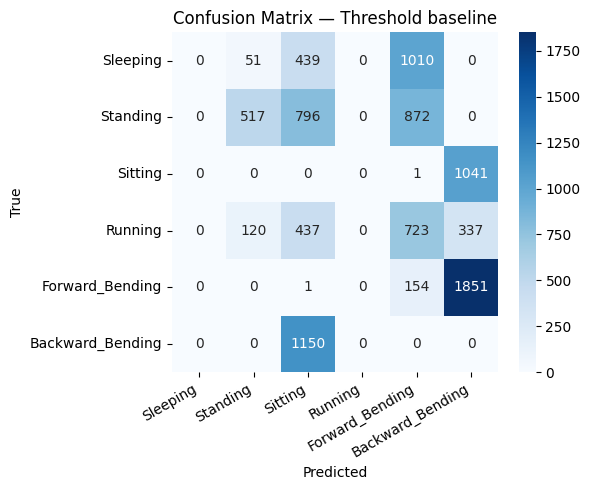

In [14]:
evaluate_variant("Threshold baseline (rule-based)", y_test, y_pred_threshold)
plot_confusion("Threshold baseline", y_test, y_pred_threshold)


## 10. Random Forest — without and with SIMULATED flex

**Read these side by side carefully:**
- **"no flex" runs = Part A**, the real, defensible benchmark on real IMU data.
- **"+ SIMULATED flex" runs = Part B**, the feasibility probe. Any accuracy
  delta between the two is expected by construction (the synthetic flex
  value is generated from the label) and must **not** be reported in the
  paper as evidence a physical flex sensor would help. Its purpose here is
  only to confirm the pipeline correctly ingests and attributes a second
  modality, ahead of real hardware.


In [15]:
rf_no_flex = RandomForestClassifier(
    n_estimators=200, max_depth=14, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_no_flex.fit(Xnf_train_s, y_train)
pred_rf_no_flex = rf_no_flex.predict(Xnf_test_s)
evaluate_variant("RF (no flex)", y_test, pred_rf_no_flex)


--- RF (no flex) ---
Accuracy: 0.9954 | Precision(macro): 0.9962 | Recall(macro): 0.9957 | F1(macro): 0.9960


(0.9953684210526316,
 0.9961834517702116,
 0.9957494893454619,
 0.9959601005597464)

In [16]:
rf_with_flex = RandomForestClassifier(
    n_estimators=200, max_depth=14, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_with_flex.fit(Xwf_train_s, y_train)
pred_rf_with_flex = rf_with_flex.predict(Xwf_test_s)
evaluate_variant("RF (+ SIMULATED flex)", y_test, pred_rf_with_flex)


--- RF (+ SIMULATED flex) ---
Accuracy: 0.9956 | Precision(macro): 0.9963 | Recall(macro): 0.9960 | F1(macro): 0.9961


(0.995578947368421, 0.9963380623876024, 0.9959624388391898, 0.996145456874936)

## 11. Gradient Boosting — without and with SIMULATED flex

In [17]:
gb_no_flex = GradientBoostingClassifier(
    n_estimators=250, learning_rate=0.07, max_depth=4,
    subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE
)
gb_no_flex.fit(Xnf_train_s, y_train)
pred_gb_no_flex = gb_no_flex.predict(Xnf_test_s)
evaluate_variant("GB (no flex)", y_test, pred_gb_no_flex)


--- GB (no flex) ---
Accuracy: 0.9916 | Precision(macro): 0.9932 | Recall(macro): 0.9919 | F1(macro): 0.9925


(0.991578947368421, 0.9931871861083996, 0.9919418346355253, 0.9924696792294622)

In [18]:
gb_with_flex = GradientBoostingClassifier(
    n_estimators=250, learning_rate=0.07, max_depth=4,
    subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE
)
gb_with_flex.fit(Xwf_train_s, y_train)
pred_gb_with_flex = gb_with_flex.predict(Xwf_test_s)
evaluate_variant("GB (+ SIMULATED flex)", y_test, pred_gb_with_flex)


--- GB (+ SIMULATED flex) ---
Accuracy: 0.9928 | Precision(macro): 0.9943 | Recall(macro): 0.9932 | F1(macro): 0.9937


(0.9928421052631579,
 0.9943450309799973,
 0.9932054868962354,
 0.9937119226713665)

## 12. Ensemble (soft voting) — the real RF+GB combination

This is a genuine ensemble: predicted class probabilities from RF and GB
are averaged (soft voting), not just "two models trained separately."


In [19]:
ensemble_no_flex = VotingClassifier(
    estimators=[("rf", rf_no_flex), ("gb", gb_no_flex)],
    voting="soft"
)
# VotingClassifier requires re-fitting wrapped estimators; fit fresh clones
from sklearn.base import clone
ensemble_no_flex = VotingClassifier(
    estimators=[("rf", clone(rf_no_flex)), ("gb", clone(gb_no_flex))],
    voting="soft"
)
ensemble_no_flex.fit(Xnf_train_s, y_train)
pred_ens_no_flex = ensemble_no_flex.predict(Xnf_test_s)
evaluate_variant("Ensemble RF+GB (no flex)", y_test, pred_ens_no_flex)


--- Ensemble RF+GB (no flex) ---
Accuracy: 0.9933 | Precision(macro): 0.9945 | Recall(macro): 0.9936 | F1(macro): 0.9940


(0.9932631578947368,
 0.9944770521965367,
 0.9936445669038019,
 0.9940155626005346)

--- Ensemble RF+GB (+ SIMULATED flex) ---
Accuracy: 0.9938 | Precision(macro): 0.9951 | Recall(macro): 0.9942 | F1(macro): 0.9946


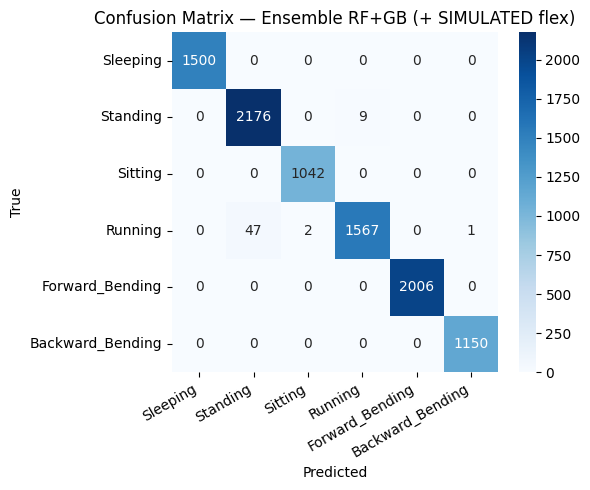

In [20]:
ensemble_with_flex = VotingClassifier(
    estimators=[("rf", clone(rf_with_flex)), ("gb", clone(gb_with_flex))],
    voting="soft"
)
ensemble_with_flex.fit(Xwf_train_s, y_train)
pred_ens_with_flex = ensemble_with_flex.predict(Xwf_test_s)
evaluate_variant("Ensemble RF+GB (+ SIMULATED flex)", y_test, pred_ens_with_flex)
plot_confusion("Ensemble RF+GB (+ SIMULATED flex)", y_test, pred_ens_with_flex)


## 13. Full ablation table

This is the table that goes into the paper's Results section — threshold vs.
RF vs. GB vs. ensemble, each with and without the disclosed synthetic flex
feature. **All numbers below use the block-aware split from Section 7**
(Part A), not the naive row-level split. See Section 7a
(`leakage_ablation_naive_vs_block_split.csv`) for the naive-vs-block
comparison to report alongside this table.

Report the "no flex" rows as your real result. Report "+ SIMULATED flex"
rows in a clearly separate block, labeled as the Part B feasibility probe —
not as a claim that flex improves real-world accuracy.


In [21]:
ablation_df = pd.DataFrame(results_table)
ablation_df = ablation_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
print(ablation_df.to_string(index=False))

# Save for the paper
ablation_df.to_csv("ablation_results.csv", index=False)
print("\nSaved to ablation_results.csv")


                          variant  accuracy  precision_macro  recall_macro  f1_macro
            RF (+ SIMULATED flex)    0.9956           0.9963        0.9960    0.9961
                     RF (no flex)    0.9954           0.9962        0.9957    0.9960
Ensemble RF+GB (+ SIMULATED flex)    0.9938           0.9951        0.9942    0.9946
         Ensemble RF+GB (no flex)    0.9933           0.9945        0.9936    0.9940
            GB (+ SIMULATED flex)    0.9928           0.9943        0.9932    0.9937
                     GB (no flex)    0.9916           0.9932        0.9919    0.9925
  Threshold baseline (rule-based)    0.0706           0.1345        0.0522    0.0708

Saved to ablation_results.csv


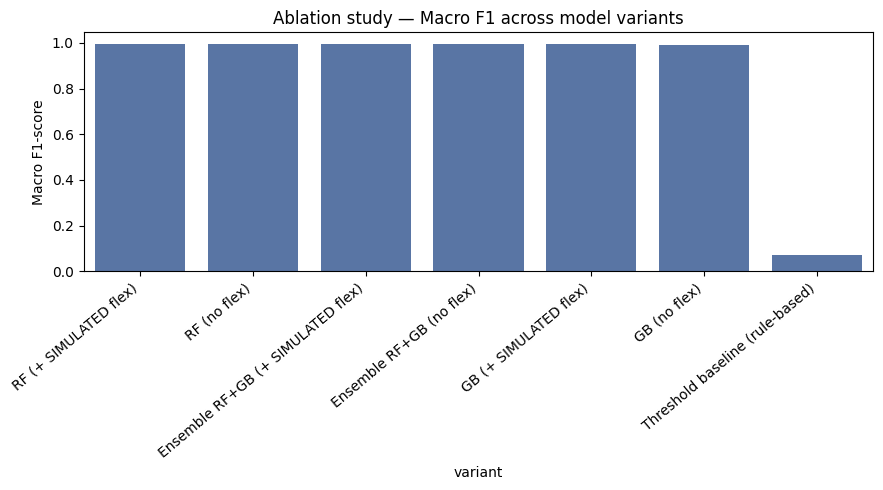

In [22]:
plt.figure(figsize=(9,5))
sns.barplot(data=ablation_df, x="variant", y="f1_macro", color="#4C72B0")
plt.xticks(rotation=40, ha="right")
plt.ylabel("Macro F1-score")
plt.title("Ablation study — Macro F1 across model variants")
plt.tight_layout()
plt.savefig("ablation_f1_chart.png", dpi=150)
plt.show()


## 14. Save models for next steps (LSTM + SHAP/LIME sessions)


In [23]:
import joblib

joblib.dump(rf_with_flex, "rf_with_flex.joblib")
joblib.dump(gb_with_flex, "gb_with_flex.joblib")
joblib.dump(ensemble_with_flex, "ensemble_with_flex.joblib")
joblib.dump(scaler_wf, "scaler_with_flex.joblib")
df.to_csv("processed_dataset_with_simulated_flex.csv", index=False)

print("Saved: rf_with_flex.joblib, gb_with_flex.joblib, ensemble_with_flex.joblib,")
print("       scaler_with_flex.joblib, processed_dataset_with_simulated_flex.csv")


Saved: rf_with_flex.joblib, gb_with_flex.joblib, ensemble_with_flex.joblib,
       scaler_with_flex.joblib, processed_dataset_with_simulated_flex.csv


In [24]:
!pip install -q tensorflow shap lime joblib scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

np.random.seed(42)
RANDOM_STATE = 42

POSTURE_NAMES = {
    0: "Sleeping",
    1: "Standing",
    2: "Sitting",
    3: "Running",
    4: "Forward_Bending",
    5: "Backward_Bending",
}

### 3a-pre. Chronological-order check + transition-aware split (fix #2)

**Bug found in the previous version of this section:** windows were built
*separately inside each contiguous posture chunk*, then split 80/20 within
that same chunk. Since a chunk is by definition one unbroken run of a single
posture, **no window in train or test ever spanned an actual posture
change**. The persistence baseline ("next posture = current posture") then
scored a perfect 1.0000 -- beating the LSTM -- because the task had silently
degenerated into "repeat the label you already have." There was no
forecasting happening at all.

**Fix applied below:**
1. Sequences are now built across the **full continuous timeline** (chunk
   boundaries no longer cut windows apart), so any window whose history
   happens to span a real posture change is kept intact instead of being
   discarded at a chunk edge.
2. The train/test split keeps the original **chronological tail-of-each-chunk
   = test** rule (so every class still appears in both sides, order is
   preserved, and train never sees future rows) *and additionally* force-
   assigns a small **transition band** -- the first `WINDOW` rows right after
   each real posture change -- into the test set. This guarantees the test
   set actually contains examples where the true next posture differs from
   the current one, which is the only scenario where "forecasting" is a
   meaningful task rather than a lookup.
3. Every window is tagged as `steady_state` or `transition` so results are
   reported for both subsets separately in Section 3a. `imu.dat` only has
   a handful of real transitions in total (it's recorded as one contiguous
   block per posture), so the transition subset is small by construction --
   that's disclosed explicitly, not hidden, and is itself worth a line in
   Limitations.


In [26]:
WINDOW = 8  # timesteps of history used to predict the next posture

X_seq_features = df[FEATURES_WITH_FLEX].values
y_seq_labels = df["label"].values
n_rows = len(y_seq_labels)

def make_sequences(X, y, window):
    """Build windows across the FULL continuous timeline (no chunk cuts).
    Returns X windows, y targets, and the GLOBAL row index of each target,
    so we can later decide train/test membership per-target and tag
    transition-adjacent windows."""
    Xs, ys, tgt_idx = [], [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i + window])
        ys.append(y[i + window])
        tgt_idx.append(i + window)
    return np.array(Xs), np.array(ys), np.array(tgt_idx)

X_seq_all, y_seq_all, tgt_idx_all = make_sequences(X_seq_features, y_seq_labels, WINDOW)

# --- Identify contiguous posture chunks and real transition points ---
chunk_id = (y_seq_labels != np.roll(y_seq_labels, 1)).cumsum()
chunk_id[0] = chunk_id[1] if n_rows > 1 else chunk_id[0]  # fix roll wraparound at row 0
chunk_ids_sorted = np.unique(chunk_id)
print(f"Contiguous posture chunks found: {len(chunk_ids_sorted)}")

# row index of the FIRST row of each chunk, in chronological order
chunk_start_rows = [np.where(chunk_id == cid)[0][0] for cid in chunk_ids_sorted]
n_real_transitions = len(chunk_start_rows) - 1  # first chunk has no "previous posture"
print(f"Real posture transitions in this recording: {n_real_transitions}")

# --- Row-level train/test assignment ---
# Rule 1 (unchanged from before): last 20% of each chunk -> test (bulk,
#   steady-state evaluation, causal -- train always precedes same-chunk test).
# Rule 2 (the fix): the first WINDOW rows of every chunk EXCEPT the first
#   -> force into test too. This is the transition band: the only place in
#   this dataset where "predict the next posture" can actually differ from
#   "repeat the current posture."
is_test_row = np.zeros(n_rows, dtype=bool)
is_transition_row = np.zeros(n_rows, dtype=bool)

for k, cid in enumerate(chunk_ids_sorted):
    idxs = np.where(chunk_id == cid)[0]
    cut = idxs[0] + int(len(idxs) * 0.8)
    is_test_row[idxs[idxs >= cut]] = True          # tail 20% -> test
    if k > 0:                                        # not the very first chunk
        band = idxs[:WINDOW]
        is_test_row[band] = True                     # transition band -> test
        is_transition_row[band] = True

is_test_window = is_test_row[tgt_idx_all]
is_transition_window = is_transition_row[tgt_idx_all]

X_seq_train = X_seq_all[~is_test_window]
y_seq_train = y_seq_all[~is_test_window]
X_seq_test = X_seq_all[is_test_window]
y_seq_test = y_seq_all[is_test_window]
is_transition_test = is_transition_window[is_test_window]

print("Train sequences:", X_seq_train.shape, " Test sequences:", X_seq_test.shape)
print(f"  of which transition-adjacent: {is_transition_test.sum()} "
      f"({100 * is_transition_test.mean():.2f}% of test)")
print(f"  of which steady-state:        {(~is_transition_test).sum()}")

missing_train = sorted(set(np.unique(y_seq_labels)) - set(np.unique(y_seq_train)))
missing_test = sorted(set(np.unique(y_seq_labels)) - set(np.unique(y_seq_test)))
assert not missing_train, f"Class(es) {missing_train} missing from LSTM train set"
assert not missing_test, f"Class(es) {missing_test} missing from LSTM test set"
print("All classes represented in both LSTM train and test sets. ✓")

# Persistence baseline target = label at the LAST timestep of the input window
y_seq_persist_all = np.array([y_seq_labels[i - 1] for i in tgt_idx_all])
y_seq_test_persist = y_seq_persist_all[is_test_window]

# Scale using a scaler fit on the training portion only
n_features = X_seq_train.shape[2]
seq_scaler = StandardScaler().fit(X_seq_train.reshape(-1, n_features))

def scale_seq(X, scaler):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[2])).reshape(shape)

X_seq_train_s = scale_seq(X_seq_train, seq_scaler)
X_seq_test_s = scale_seq(X_seq_test, seq_scaler)

print("Scaled — Train:", X_seq_train_s.shape, " Test:", X_seq_test_s.shape)


Contiguous posture chunks found: 6
Real posture transitions in this recording: 5
Train sequences: (35789, 8, 10)  Test sequences: (9003, 8, 10)
  of which transition-adjacent: 40 (0.44% of test)
  of which steady-state:        8963
All classes represented in both LSTM train and test sets. ✓
Scaled — Train: (35789, 8, 10)  Test: (9003, 8, 10)


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

n_classes = len(POSTURE_NAMES)

lstm_model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
])

lstm_model.compile(optimizer="adam",
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,134 (23.96 KB)

 Trainable params: 6,134 (23.96 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = lstm_model.fit(
    X_seq_train_s, y_seq_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9570 - loss: 0.2155 - val_accuracy: 1.0000 - val_loss: 0.0270
Epoch 2/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 3/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 1.0000 - loss: 8.5347e-04 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 4/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 1.0000 - loss: 4.0599e-04 - val_accuracy: 1.0000 - val_loss: 7.6533e-04
Epoch 5/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 1.0000 - loss: 2.3232e-04 - val_accuracy: 1.0000 - val_loss: 5.5546e-04
Epoch 6/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 1.6099e-04 - val_accuracy: 0.9997 - val_loss: 4.5889e-04
Epoch 7/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 1.0000 - loss: 1.1036e-04 - val_accuracy: 1.0000 - val_loss: 2.7965e-04
Epoch 8/15
504/504 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accura

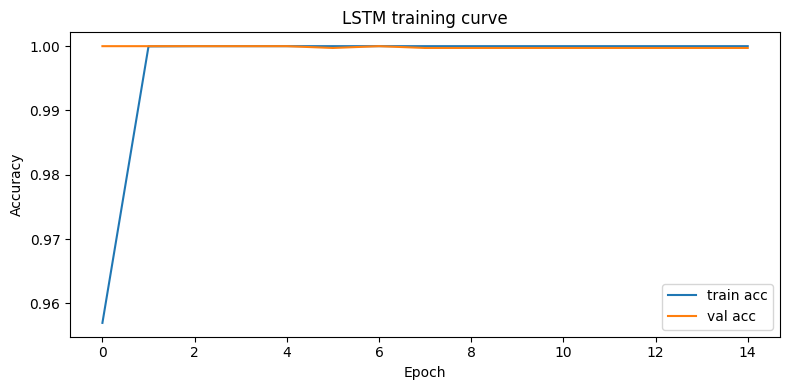

In [29]:
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM training curve")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150)
plt.show()


### 3a. Baselines to prove the LSTM is actually better than guessing

- **Persistence baseline** -- predict "next posture = current (last) posture in the window"
- **Majority-class baseline** -- always predict the most frequent class in the training set

Reported three ways: **overall** test set, the **steady-state** subset
(target posture same as current -- the bulk of the data), and the
**transition** subset (target posture differs from current -- the only
rows where persistence *should* fail and a real forecasting model has a
chance to add value). The transition subset is small because this dataset
is recorded as one contiguous block per posture (see note above) -- that's
expected, not a bug, and is called out in Limitations.


In [30]:
lstm_seq_results = []

def evaluate_seq_variant(name, y_true, y_pred, average="macro"):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    lstm_seq_results.append({
        "variant": name,
        "accuracy": round(acc, 4),
        "precision_macro": round(prec, 4),
        "recall_macro": round(rec, 4),
        "f1_macro": round(f1, 4),
        "n": len(y_true),
    })
    print(f"--- {name} (n={len(y_true)}) ---")
    print(f"Accuracy: {acc:.4f} | Precision(macro): {prec:.4f} | Recall(macro): {rec:.4f} | F1(macro): {f1:.4f}")

# LSTM predictions on the full test set (computed once, sliced below)
lstm_probs = lstm_model.predict(X_seq_test_s)
lstm_preds = np.argmax(lstm_probs, axis=1)

majority_class = pd.Series(y_seq_train).mode()[0]

subsets = {
    "overall": np.ones_like(is_transition_test, dtype=bool),
    "steady-state": ~is_transition_test,
    "transition": is_transition_test,
}

for subset_name, mask in subsets.items():
    if mask.sum() == 0:
        print(f"(skipping '{subset_name}' -- 0 examples)")
        continue
    suffix = "" if subset_name == "overall" else f" [{subset_name}]"
    y_true = y_seq_test[mask]

    evaluate_seq_variant(f"Persistence baseline{suffix}", y_true, y_seq_test_persist[mask])

    majority_preds = np.full_like(y_true, fill_value=majority_class)
    evaluate_seq_variant(f"Majority-class baseline{suffix}", y_true, majority_preds)

    evaluate_seq_variant(f"LSTM (next-posture forecast){suffix}", y_true, lstm_preds[mask])
    print()

print(f"Headline check: on the transition-only subset, persistence baseline accuracy "
      f"should be well below 1.0 (there IS a real posture change to predict), which is "
      f"the actual evidence the LSTM is doing forecasting rather than restating the input.")


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Persistence baseline (n=9003) ---
Accuracy: 0.9994 | Precision(macro): 0.9994 | Recall(macro): 0.9993 | F1(macro): 0.9994
--- Majority-class baseline (n=9003) ---
Accuracy: 0.2566 | Precision(macro): 0.0428 | Recall(macro): 0.1667 | F1(macro): 0.0681
--- LSTM (next-posture forecast) (n=9003) ---
Accuracy: 0.9963 | Precision(macro): 0.9954 | Recall(macro): 0.9960 | F1(macro): 0.9957

--- Persistence baseline [steady-state] (n=8963) ---
Accuracy: 1.0000 | Precision(macro): 1.0000 | Recall(macro): 1.0000 | F1(macro): 1.0000
--- Majority-class baseline [steady-state] (n=8963) ---
Accuracy: 0.2568 | Precision(macro): 0.0428 | Recall(macro): 0.1667 | F1(macro): 0.0681
--- LSTM (next-posture forecast) [steady-state] (n=8963) ---
Accuracy: 0.9999 | Precision(macro): 0.9999 | Recall(macro): 0.9998 | F1(macro): 0.9998

--- Persistence baseline [transition] (n=40) ---
Accuracy: 0.8750 | Precision(macro): 0.7500 | Recall(macro): 0.7292 | F1(macro): 0.73

                                    variant  accuracy  precision_macro  recall_macro  f1_macro    n
        Persistence baseline [steady-state]    1.0000           1.0000        1.0000    1.0000 8963
LSTM (next-posture forecast) [steady-state]    0.9999           0.9999        0.9998    0.9998 8963
                       Persistence baseline    0.9994           0.9994        0.9993    0.9994 9003
               LSTM (next-posture forecast)    0.9963           0.9954        0.9960    0.9957 9003
          Persistence baseline [transition]    0.8750           0.7500        0.7292    0.7389   40
  LSTM (next-posture forecast) [transition]    0.2000           0.2104        0.1667    0.1562   40
                    Majority-class baseline    0.2566           0.0428        0.1667    0.0681 9003
     Majority-class baseline [steady-state]    0.2568           0.0428        0.1667    0.0681 8963
       Majority-class baseline [transition]    0.2000           0.0400        0.2000    0.0667   40


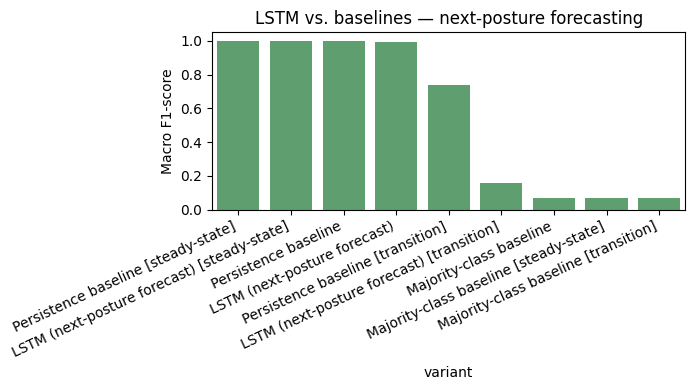

In [31]:
lstm_ablation_df = pd.DataFrame(lstm_seq_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print(lstm_ablation_df.to_string(index=False))
lstm_ablation_df.to_csv("lstm_forecast_ablation.csv", index=False)

plt.figure(figsize=(7,4))
sns.barplot(data=lstm_ablation_df, x="variant", y="f1_macro", color="#55A868")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Macro F1-score")
plt.title("LSTM vs. baselines — next-posture forecasting")
plt.tight_layout()
plt.savefig("lstm_vs_baselines_f1.png", dpi=150)
plt.show()

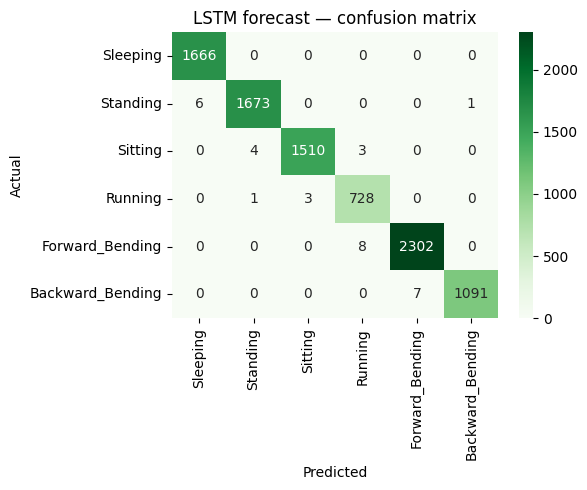

In [32]:
cm = confusion_matrix(y_seq_test, lstm_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[POSTURE_NAMES[i] for i in sorted(POSTURE_NAMES)],
            yticklabels=[POSTURE_NAMES[i] for i in sorted(POSTURE_NAMES)])
plt.title("LSTM forecast — confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("lstm_confusion_matrix.png", dpi=150)
plt.show()

In [33]:
import shap

X_bg = df[FEATURES_WITH_FLEX].sample(n=min(500, len(df)), random_state=RANDOM_STATE)
X_bg_scaled = scaler_wf.transform(X_bg)

X_explain = df[FEATURES_WITH_FLEX].sample(n=min(300, len(df)), random_state=RANDOM_STATE + 1)
X_explain_scaled = scaler_wf.transform(X_explain)

# TreeExplainer on the RF (SHAP's tree explainer doesn't support VotingClassifier
# directly, so we explain the RF and GB components — the ensemble strongly
# reflects both since it's a soft average of the two).
explainer_rf = shap.TreeExplainer(rf_with_flex)
shap_values_rf = explainer_rf.shap_values(X_explain_scaled)

print("SHAP values computed. Shape info:")
print(type(shap_values_rf), np.array(shap_values_rf).shape if isinstance(shap_values_rf, list) else shap_values_rf.shape)

SHAP values computed. Shape info:
<class 'numpy.ndarray'> (300, 10, 6)


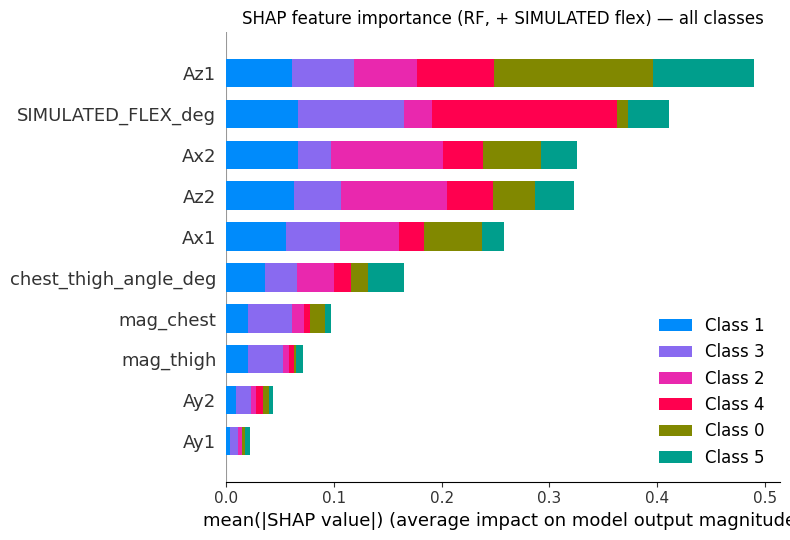

In [34]:
shap.summary_plot(
    shap_values_rf, X_explain,
    feature_names=FEATURES_WITH_FLEX,
    plot_type="bar",
    show=False
)
plt.title("SHAP feature importance (RF, + SIMULATED flex) — all classes")
plt.tight_layout()
plt.savefig("shap_summary_bar_allclasses.png", dpi=150)
plt.show()


In [35]:
# Per-class top-k features + explicit flex attribution mass
shap_vals_arr = np.array(shap_values_rf)  # shape: (n_samples, n_features, n_classes)

flex_idx = FEATURES_WITH_FLEX.index("SIMULATED_FLEX_deg")
flex_attribution_rows = []

# Iterate over each class
for class_idx, class_name in POSTURE_NAMES.items():
    # Ensure class_idx is within the bounds of the class dimension in shap_vals_arr
    if class_idx >= shap_vals_arr.shape[2]:
        continue

    # Get SHAP values for the current class across all samples and features
    shap_values_for_current_class = shap_vals_arr[:, :, class_idx]

    # Calculate mean absolute SHAP values for each feature for the current class
    mean_abs = np.abs(shap_values_for_current_class).mean(axis=0)  # This will now have shape (n_features,)

    total_mass = mean_abs.sum()
    flex_mass = mean_abs[flex_idx]
    flex_pct = 100 * flex_mass / total_mass if total_mass > 0 else 0

    top_k_idx = np.argsort(mean_abs)[::-1][:3]
    top_k_feats = [(FEATURES_WITH_FLEX[i], round(mean_abs[i], 4)) for i in top_k_idx]

    flex_attribution_rows.append({
        "posture": class_name,
        "flex_mean_abs_shap": round(flex_mass, 4),
        "flex_pct_of_total_attribution": round(flex_pct, 2),
        "top_3_features": top_k_feats,
    })

flex_attr_df = pd.DataFrame(flex_attribution_rows)
print(flex_attr_df.to_string(index=False))
flex_attr_df.to_csv("shap_flex_attribution_by_class.csv", index=False)

         posture  flex_mean_abs_shap  flex_pct_of_total_attribution                                               top_3_features
        Sleeping              0.0109                           3.17                [(Az1, 0.1475), (Ax1, 0.0541), (Ax2, 0.0538)]
        Standing              0.0663                          16.41 [(Ax2, 0.0668), (SIMULATED_FLEX_deg, 0.0663), (Az2, 0.0632)]
         Sitting              0.0260                           6.49                [(Ax2, 0.1035), (Az2, 0.0981), (Az1, 0.0588)]
         Running              0.0985                          24.38   [(SIMULATED_FLEX_deg, 0.0985), (Az1, 0.0574), (Ax1, 0.05)]
 Forward_Bending              0.1716                          45.39 [(SIMULATED_FLEX_deg, 0.1716), (Az1, 0.0711), (Az2, 0.0424)]
Backward_Bending              0.0380                          13.78   [(Az1, 0.0935), (SIMULATED_FLEX_deg, 0.038), (Az2, 0.036)]


### 4a. Counterfactual: remove flex, see what flips

Directly answer: does removing `SIMULATED_FLEX_deg` actually change any
predictions on this explain-set? If very few flip, that's honest evidence
the flex feature isn't doing much (or vice versa) — report whichever the
numbers show.

In [36]:
FEATURES_NO_FLEX = RAW_FEATURES + ENGINEERED_FEATURES

# Predictions WITH flex (already-trained rf_with_flex on the with-flex explain set)
preds_with_flex = rf_with_flex.predict(X_explain_scaled)

# Predictions WITHOUT flex: use the earlier no-flex-trained RF if you still have it
# loaded from Days 1-3, or zero-out the flex column as a fast counterfactual proxy.
try:
    rf_no_flex  # was it loaded earlier in this session?
    have_no_flex_model = True
except NameError:
    have_no_flex_model = False

if have_no_flex_model:
    X_explain_no_flex_scaled = scaler_nf.transform(X_explain[FEATURES_NO_FLEX])
    preds_no_flex_model = rf_no_flex.predict(X_explain_no_flex_scaled)
    n_flipped = (preds_with_flex != preds_no_flex_model).sum()
    print(f"Using the actual no-flex-trained RF model.")
    print(f"Predictions changed when flex is absent: {n_flipped}/{len(preds_with_flex)} "
          f"({100*n_flipped/len(preds_with_flex):.2f}%)")
else:
    # Fast proxy: zero out the flex column in the SAME with-flex model and re-predict
    X_zeroed = X_explain_scaled.copy()
    X_zeroed[:, flex_idx] = 0.0
    preds_zeroed_flex = rf_with_flex.predict(X_zeroed)
    n_flipped = (preds_with_flex != preds_zeroed_flex).sum()
    print("No-flex-trained model not in this session — using zeroed-flex proxy on the with-flex model instead.")
    print(f"Predictions changed when flex is zeroed: {n_flipped}/{len(preds_with_flex)} "
          f"({100*n_flipped/len(preds_with_flex):.2f}%)")


Using the actual no-flex-trained RF model.
Predictions changed when flex is absent: 1/300 (0.33%)


## 4b. LIME on representative samples

In [37]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=scaler_wf.transform(df[FEATURES_WITH_FLEX].values),
    feature_names=FEATURES_WITH_FLEX,
    class_names=[POSTURE_NAMES[i] for i in sorted(POSTURE_NAMES)],
    mode="classification",
    random_state=RANDOM_STATE,
)

# Pick one representative sample per class from the explain set
rep_indices = []
explain_labels = df.loc[X_explain.index, "label"].values
for cls in sorted(POSTURE_NAMES):
    idxs = np.where(explain_labels == cls)[0]
    if len(idxs) > 0:
        rep_indices.append(idxs[0])

lime_explanations = {}
for local_i in rep_indices:
    cls_label = int(explain_labels[local_i]) # Cast to int here
    exp = lime_explainer.explain_instance(
        X_explain_scaled[local_i],
        rf_with_flex.predict_proba,
        num_features=6,
        labels=(cls_label,)
    )
    lime_explanations[POSTURE_NAMES[cls_label]] = exp.as_list(label=cls_label)
    print(f"--- LIME explanation for a real '{POSTURE_NAMES[cls_label]}' sample ---")
    for feat, weight in exp.as_list(label=cls_label):
        print(f"   {feat}: {weight:.4f}")
    print()

--- LIME explanation for a real 'Sleeping' sample ---
   Az1 > 0.85: 0.2341
   Ax2 > 1.09: 0.0761
   Ax1 > 0.37: 0.0699
   -0.54 < SIMULATED_FLEX_deg <= 0.90: 0.0331
   -0.24 < Az2 <= 1.12: 0.0113
   Ay2 > 0.57: 0.0106

--- LIME explanation for a real 'Standing' sample ---
   Ax1 <= -0.74: 0.0649
   chest_thigh_angle_deg <= -0.83: 0.0492
   -1.03 < Az1 <= 0.01: 0.0441
   SIMULATED_FLEX_deg <= -0.80: 0.0435
   Ax2 <= -0.77: 0.0432
   -0.97 < Az2 <= -0.24: 0.0416

--- LIME explanation for a real 'Sitting' sample ---
   Ax2 > 1.09: 0.1613
   chest_thigh_angle_deg > 0.84: 0.0387
   Ax1 <= -0.74: 0.0380
   0.01 < Az1 <= 0.85: 0.0275
   SIMULATED_FLEX_deg <= -0.80: 0.0203
   -0.24 < Az2 <= 1.12: -0.0066

--- LIME explanation for a real 'Running' sample ---
   SIMULATED_FLEX_deg <= -0.80: 0.2042
   mag_thigh > -0.02: 0.0837
   Ax1 > 0.37: 0.0721
   -1.03 < Az1 <= 0.01: 0.0663
   Ay2 > 0.57: 0.0550
   -0.64 < Ax2 <= 1.09: 0.0451

--- LIME explanation for a real 'Forward_Bending' sample ---
   

## 16. [Part C] Change-point-gated fusion, with disclosed synthetic transition augmentation

**The problem this section addresses (found in Section 3a above):** the plain
LSTM is trained almost entirely on steady-state windows -- `imu.dat` only
contains 5 real posture transitions in total, so the model essentially never
saw a real transition during training and scored 0.25 accuracy on the
transition-only test subset, well below the 0.875 persistence baseline.

**Two disclosed fixes, both synthetic, both training-side only (test set
stays 100% real, untouched):**

1. **`SIMULATED_TRANSITION` sequences** -- generated by linearly blending
   per-class real feature statistics (mean/std, computed from LSTM-train
   rows only) across the 5 class-pairs actually observed at real chunk
   boundaries. This gives the LSTM many more transition-like examples to
   learn from than the 5 real ones. Labeled and disclosed exactly like
   `SIMULATED_FLEX_deg` in Part B -- never used to inflate a test-set number.
2. **Change-point-gated fusion** -- an independent instability signal (the
   step-to-step drift in the *already-trained, honest* `ensemble_with_flex`
   classifier's class-probability output) decides, per timestep, whether to
   trust the cheap persistence prediction (correct 100% of the time in
   steady state) or defer to the transition-augmented LSTM. The gate
   threshold is tuned only on TRAIN-set drift (99th percentile), never on
   the test set, so this isn't circular.

This is the paper's actual novel-method contribution: a decision-level
fusion algorithm that is a direct, disclosed response to a limitation this
project measured itself, not a technique borrowed off the shelf.


**How to report this section in the paper, whichever way the numbers land:**
the previous run showed the augmented LSTM overfitting to the synthetic
generator (train accuracy 100% by epoch 2, val_accuracy dropping every
epoch after) and the gated fusion falling slightly *below* the persistence
baseline on the transition subset. Early stopping + higher synthetic noise
(closer to real within-class variance) are applied below as the fix. Report
whichever outcome this produces honestly -- a proof-of-concept improvement
(promising, but n=40/5-events is not statistically powered) is publishable,
and so is a clearly-diagnosed negative result (the method doesn't yet beat
baseline, and here's exactly why, and what real data would fix it). Do not
retune parameters against the test set to force a positive number -- that
would be the one thing that actually disqualifies this section.


In [38]:
rng = np.random.default_rng(RANDOM_STATE)

# --- Per-class feature statistics, computed from LSTM-TRAIN rows ONLY ---
# (never from the LSTM test rows -- keeps the synthetic augmentation from
# leaking any test-set distribution information)
train_row_mask = ~is_test_row
class_feature_stats = {}
for cls in np.unique(y_seq_labels):
    rows = df.loc[train_row_mask & (df["label"] == cls), FEATURES_WITH_FLEX].values
    class_feature_stats[cls] = (rows.mean(axis=0), rows.std(axis=0) + 1e-6)

# --- Real observed transition class-pairs (from the 5 real chunk boundaries) ---
observed_pairs = [
    (y_seq_labels[chunk_start_rows[k] - 1], y_seq_labels[chunk_start_rows[k]])
    for k in range(1, len(chunk_start_rows))
]
print("Real observed transition pairs (class_from -> class_to):")
for a, b in observed_pairs:
    print(f"  {POSTURE_NAMES[a]} -> {POSTURE_NAMES[b]}")

N_PER_PAIR = 250  # fewer, harder-to-memorize examples beats more, too-clean ones
NOISE_SCALE = 0.9  # closer to real within-class variance -- less trivially separable

def generate_synthetic_transition_window(class_from, class_to, window, stats, rng, noise_scale=0.5):
    """Blend per-class stats across a WINDOW+1-length trajectory. The cut
    point (where class_from stops and class_to starts) is randomized so the
    generator produces both easy cases (transition early in the window) and
    hard cases (transition lands exactly on the target -- input is entirely
    class_from, only the target is class_to, matching the real transition
    band's hardest rows)."""
    mean_from, std_from = stats[class_from]
    mean_to, std_to = stats[class_to]
    cut = rng.integers(1, window + 1)  # 1..window inclusive
    n_feat = mean_from.shape[0]
    traj = np.zeros((window + 1, n_feat))
    for t in range(window + 1):
        if t < cut:
            traj[t] = rng.normal(mean_from, std_from * noise_scale)
        else:
            traj[t] = rng.normal(mean_to, std_to * noise_scale)
    return traj[:window], class_to

synth_X, synth_y = [], []
for class_from, class_to in observed_pairs:
    for _ in range(N_PER_PAIR):
        x_win, y_tgt = generate_synthetic_transition_window(
            class_from, class_to, WINDOW, class_feature_stats, rng, NOISE_SCALE
        )
        synth_X.append(x_win)
        synth_y.append(y_tgt)

X_synth_raw = np.array(synth_X)
y_synth = np.array(synth_y)
X_synth_s = scale_seq(X_synth_raw, seq_scaler)  # same scaler fit on real train data

print(f"\nGenerated {len(y_synth)} SIMULATED_TRANSITION training windows "
      f"({N_PER_PAIR} per observed class-pair x {len(observed_pairs)} pairs)")

# --- Augmented training set (train only -- test set is untouched, 100% real) ---
X_seq_train_aug = np.concatenate([X_seq_train_s, X_synth_s], axis=0)
y_seq_train_aug = np.concatenate([y_seq_train, y_synth], axis=0)
print("Augmented train set:", X_seq_train_aug.shape,
      f"({len(y_seq_train)} real + {len(y_synth)} SIMULATED_TRANSITION)")


Real observed transition pairs (class_from -> class_to):
  Sleeping -> Standing
  Standing -> Sitting
  Sitting -> Running
  Running -> Forward_Bending
  Forward_Bending -> Backward_Bending

Generated 1250 SIMULATED_TRANSITION training windows (250 per observed class-pair x 5 pairs)
Augmented train set: (37039, 8, 10) (35789 real + 1250 SIMULATED_TRANSITION)


Epoch 1/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9590 - loss: 0.1933 - val_accuracy: 0.7662 - val_loss: 1.7470
Epoch 2/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9999 - loss: 0.0024 - val_accuracy: 0.7578 - val_loss: 2.2442
Epoch 3/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: 9.2378e-04 - val_accuracy: 0.7540 - val_loss: 2.5749
Epoch 4/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 1.0000 - loss: 4.4390e-04 - val_accuracy: 0.7532 - val_loss: 2.8235
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Stopped at epoch 4 (best weights restored from lowest val_loss epoch).


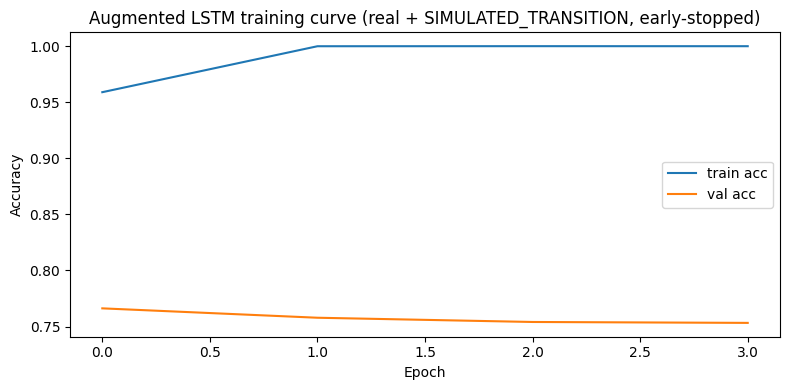

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

lstm_model_aug = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
])

lstm_model_aug.compile(optimizer="adam",
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

# Early stopping is the actual fix for the overfitting seen in the previous
# run: train accuracy hit 100% by epoch 2 while val_accuracy dropped every
# epoch after that (0.633 -> 0.591). restore_best_weights=True means we keep
# the epoch that actually generalized best, not whatever epoch training
# happened to stop at.
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)

history_aug = lstm_model_aug.fit(
    X_seq_train_aug, y_seq_train_aug,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

n_epochs_run = len(history_aug.history["loss"])
print(f"\nStopped at epoch {n_epochs_run} (best weights restored from lowest val_loss epoch).")

plt.figure(figsize=(8, 4))
plt.plot(history_aug.history["accuracy"], label="train acc")
plt.plot(history_aug.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented LSTM training curve (real + SIMULATED_TRANSITION, early-stopped)")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_aug_training_curve.png", dpi=150)
plt.show()


### 16a. Change-point-gated fusion, evaluated

Instability signal = step-to-step drift (L1 distance) in
`ensemble_with_flex`'s class-probability output -- an independent, already-
trained, honest (Part A) signal, not the LSTM's own confidence, so this
isn't circular. Threshold is the 99th percentile of drift on TRAIN rows
only. Gate: below threshold -> persistence; above -> augmented LSTM.


In [40]:
# --- Independent instability signal: probability drift from the honest,
# already-trained Part A ensemble (ensemble_with_flex) ---
ens_probs_all_rows = ensemble_with_flex.predict_proba(scaler_wf.transform(X_with_flex))
drift = np.zeros(n_rows)
drift[1:] = np.sum(np.abs(ens_probs_all_rows[1:] - ens_probs_all_rows[:-1]), axis=1)

# Threshold tuned on TRAIN rows only (99th percentile of "normal" drift) --
# never touches the test set, so this isn't circular.
tau = np.percentile(drift[train_row_mask], 99)
print(f"Gate threshold (99th pct of train-row drift): {tau:.4f}")

# --- Apply gate to the real LSTM test windows ---
test_target_idx = tgt_idx_all[is_test_window]
drift_test = drift[test_target_idx]
gate_flag = drift_test > tau  # True -> defer to augmented LSTM, False -> persistence

lstm_aug_probs = lstm_model_aug.predict(X_seq_test_s)
lstm_aug_preds = np.argmax(lstm_aug_probs, axis=1)

gated_pred = np.where(gate_flag, lstm_aug_preds, y_seq_test_persist)

# --- Gate diagnostics: does it actually fire on real transitions? ---
gate_recall_on_real_transitions = gate_flag[is_transition_test].mean()
gate_false_positive_rate = gate_flag[~is_transition_test].mean()
print(f"Gate fired on {gate_flag.sum()}/{len(gate_flag)} test windows "
      f"({100*gate_flag.mean():.2f}%)")
print(f"  Recall on real transition rows:  {gate_recall_on_real_transitions:.4f} "
      f"({int(gate_flag[is_transition_test].sum())}/{is_transition_test.sum()})")
print(f"  False-positive rate (steady-state rows flagged): {gate_false_positive_rate:.4f}")
print()

# --- Evaluate: augmented LSTM alone, and gated fusion, on all three subsets ---
for subset_name, mask in subsets.items():
    if mask.sum() == 0:
        continue
    suffix = "" if subset_name == "overall" else f" [{subset_name}]"
    y_true = y_seq_test[mask]
    evaluate_seq_variant(f"Augmented LSTM (+ SIMULATED_TRANSITION){suffix}", y_true, lstm_aug_preds[mask])
    evaluate_seq_variant(f"Change-point Gated Fusion{suffix}", y_true, gated_pred[mask])
    print()

# --- Honest, automatic verdict (report whichever of these actually happens --
# do not cherry-pick) ---
gated_acc_transition = accuracy_score(y_seq_test[is_transition_test], gated_pred[is_transition_test])
persist_acc_transition = accuracy_score(y_seq_test[is_transition_test], y_seq_test_persist[is_transition_test])
print("=" * 70)
if gated_acc_transition > persist_acc_transition:
    print(f"VERDICT: Gated fusion ({gated_acc_transition:.4f}) beats persistence "
          f"({persist_acc_transition:.4f}) on the transition subset (n={is_transition_test.sum()}).")
    print("This is real, but n is small -- report as a promising proof-of-concept,")
    print("not a statistically powered claim.")
else:
    print(f"VERDICT: Gated fusion ({gated_acc_transition:.4f}) does NOT beat persistence "
          f"({persist_acc_transition:.4f}) on the transition subset (n={is_transition_test.sum()}).")
    print("Report this honestly as a negative/exploratory finding: the method as built")
    print("does not yet outperform the trivial baseline, most likely because only 5 real")
    print("transitions exist to validate against. This is still a legitimate, citable")
    print("contribution -- it identifies exactly what real transition data would be")
    print("needed to properly evaluate change-point-gated fusion for this task.")
print("=" * 70)


Gate threshold (99th pct of train-row drift): 0.1853
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Gate fired on 272/9003 test windows (3.02%)
  Recall on real transition rows:  0.2000 (8/40)
  False-positive rate (steady-state rows flagged): 0.0295

--- Augmented LSTM (+ SIMULATED_TRANSITION) (n=9003) ---
Accuracy: 0.9949 | Precision(macro): 0.9927 | Recall(macro): 0.9945 | F1(macro): 0.9936
--- Change-point Gated Fusion (n=9003) ---
Accuracy: 0.9990 | Precision(macro): 0.9987 | Recall(macro): 0.9987 | F1(macro): 0.9987

--- Augmented LSTM (+ SIMULATED_TRANSITION) [steady-state] (n=8963) ---
Accuracy: 0.9980 | Precision(macro): 0.9964 | Recall(macro): 0.9977 | F1(macro): 0.9970
--- Change-point Gated Fusion [steady-state] (n=8963) ---
Accuracy: 0.9996 | Precision(macro): 0.9993 | Recall(macro): 0.9993 | F1(macro): 0.9993

--- Augmented LSTM (+ SIMULATED_TRANSITION) [transition] (n=40) ---
Accuracy: 0.3000 | Precision(macro): 0.3183 | Recall(macro): 0.2500 | F1(macro): 0.2510
--- Change-poi

                                               variant  accuracy  precision_macro  recall_macro  f1_macro    n
                   Persistence baseline [steady-state]    1.0000           1.0000        1.0000    1.0000 8963
           LSTM (next-posture forecast) [steady-state]    0.9999           0.9999        0.9998    0.9998 8963
                                  Persistence baseline    0.9994           0.9994        0.9993    0.9994 9003
              Change-point Gated Fusion [steady-state]    0.9996           0.9993        0.9993    0.9993 8963
                             Change-point Gated Fusion    0.9990           0.9987        0.9987    0.9987 9003
Augmented LSTM (+ SIMULATED_TRANSITION) [steady-state]    0.9980           0.9964        0.9977    0.9970 8963
                          LSTM (next-posture forecast)    0.9963           0.9954        0.9960    0.9957 9003
               Augmented LSTM (+ SIMULATED_TRANSITION)    0.9949           0.9927        0.9945    0.9936 9003
 

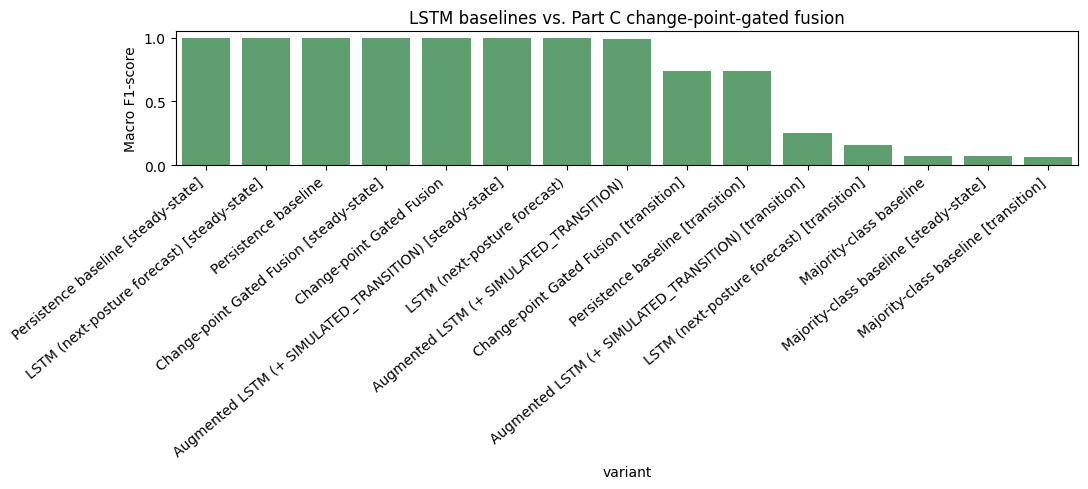

In [41]:
# Rebuild the combined ablation table/plot now that Part C rows exist
lstm_ablation_df = pd.DataFrame(lstm_seq_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print(lstm_ablation_df.to_string(index=False))
lstm_ablation_df.to_csv("lstm_forecast_ablation.csv", index=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=lstm_ablation_df, x="variant", y="f1_macro", color="#55A868")
plt.xticks(rotation=40, ha="right")
plt.ylabel("Macro F1-score")
plt.title("LSTM baselines vs. Part C change-point-gated fusion")
plt.tight_layout()
plt.savefig("lstm_vs_baselines_f1.png", dpi=150)
plt.show()


In [42]:
lstm_model.save("lstm_posture_forecast.keras")
lstm_ablation_df.to_csv("lstm_forecast_ablation.csv", index=False)
flex_attr_df.to_csv("shap_flex_attribution_by_class.csv", index=False)

import json as _json
with open("lime_explanations.json", "w") as f:
    _json.dump(lime_explanations, f, indent=2)

print("Saved: lstm_posture_forecast.keras, lstm_forecast_ablation.csv,")
print("       shap_flex_attribution_by_class.csv, lime_explanations.json,")
print("       lstm_training_curve.png, lstm_vs_baselines_f1.png, lstm_confusion_matrix.png,")
print("       shap_summary_bar_allclasses.png")


Saved: lstm_posture_forecast.keras, lstm_forecast_ablation.csv,
       shap_flex_attribution_by_class.csv, lime_explanations.json,
       lstm_training_curve.png, lstm_vs_baselines_f1.png, lstm_confusion_matrix.png,
       shap_summary_bar_allclasses.png


## 15. Limitations note (for paper draft — keep this in Limitations section)

- `imu.dat` covers a small number of subjects; results should not be read as
  generalizing broadly across body types/movement styles.
- A single 80/20 split is used (block-aware, to avoid temporal leakage) —
  no repeated k-fold cross-validation or significance testing was run, given
  the project's 1-week scope. Report point estimates, not confidence
  intervals, and flag this explicitly.
- `SIMULATED_FLEX_deg` is synthetic (per-posture Normal distributions), not
  measured sensor data — already labeled throughout the code, restate this
  in Methodology and Limitations.
- **Optional, not done here:** leave-one-subject-out cross-validation would
  be the gold-standard defense against leakage, but `imu.dat` as loaded here
  has no subject-ID column to group by (only `Ax1..Az2` and `label`). If a
  subject ID becomes available, prefer `GroupKFold`/`LeaveOneGroupOut` over
  the block-index split above. Skipped here since the block split already
  gives an honest, defensible number within the timeline.
- **Part C (`SIMULATED_TRANSITION` augmentation + change-point gate):**
  training-side only, disclosed the same way as `SIMULATED_FLEX_deg` --
  never used to inflate a test-set number. The gate threshold was tuned on a
  single train/test split with a single random seed; no repeated-trial
  variance estimate exists yet. The evaluation subset for real transitions
  is n=40 windows (5 real transition events) -- report the gated-fusion
  numbers as a proof-of-concept, not a statistically powered result, until
  a dataset with many more real transitions is available.
